# Portofolio Data Analyst - Unit 3, 4, dan 5
## Dataset: Top 5000 IMDb

Notebook ini melanjutkan pekerjaan dari Unit 1 dan Unit 2.

Unit 3 - Menelaah Data:
Melakukan eksplorasi awal dataset seperti melihat struktur data, tipe data, jumlah baris-kolom, statistik deskriptif, nilai unik, dan missing value.

Unit 4 - Memvalidasi Data:
Melakukan validasi kelengkapan data, memperbaiki missing value, mengecek duplikasi, memeriksa tipe data, dan memvalidasi batas nilai.

Unit 5 - Menentukan Objek Data:
Menentukan atribut/kolom dan record/baris yang digunakan untuk analisis, membuat korelasi fitur, visualisasi, serta menyimpan dataset bersih.

In [4]:
!nvidia-smi

Fri Jun  5 12:36:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
%%time
#import library utama
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

# Setting visualisasi
sns.set()
%matplotlib inline

#Menampilkan semua kolom
pd.set_option('display.max_columns', None)

CPU times: user 1.26 ms, sys: 27 µs, total: 1.28 ms
Wall time: 1.29 ms


# Unit 3 - Menelaah Data  
Pada bagian ini dilakukan eksplorasi awal dataset untuk memahami isi data, struktur kolom, tipe data, jumlah baris, jumlah kolom, statistik deskriptif, nilai unik, dan missing value.

## Import / Load Dataset

In [6]:
# Membaca Dataset csv
movie = pd.read_csv("Top_5000_IMDB.csv")
# Menampilkan 5 data teratas
movie.head()

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3193141,142,Frank Darabont,"Frank Darabont, Stephen King",Drama,"<a href=""https://www.imdb.com/title/tt0111161""...","<a href=""https://www.imdb.com/title/tt0111161""..."
1,tt0068646,The Godfather,1972,2,9.2,2228974,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama","<a href=""https://www.imdb.com/title/tt0068646""...","<a href=""https://www.imdb.com/title/tt0068646""..."
2,tt0468569,The Dark Knight,2008,3,9.1,3173646,152,Christopher Nolan,"David S. Goyer, Jonathan Nolan, Christopher No...","Crime, Thriller","<a href=""https://www.imdb.com/title/tt0468569""...","<a href=""https://www.imdb.com/title/tt0468569""..."
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2166974,201,Peter Jackson,"Philippa Boyens, Fran Walsh, Peter Jackson, J....","Adventure, Drama, Fantasy","<a href=""https://www.imdb.com/title/tt0167260""...","<a href=""https://www.imdb.com/title/tt0167260""..."
4,tt0108052,Schindler's List,1993,5,9.0,1586572,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History","<a href=""https://www.imdb.com/title/tt0108052""...","<a href=""https://www.imdb.com/title/tt0108052""..."


## Melihat Informasi Dasar Dataset

In [7]:
movie.shape
# Menampilkan jumlah baris dan kolom dataset
print(f"Jumlah Kolom: {movie.shape[1]}")
print(f"Jumlah baris: {movie.shape[0]}")

Jumlah Kolom: 12
Jumlah baris: 5000


In [8]:
# Menampilkan nama-nama kolom
movie.columns

Index(['tconst', 'primaryTitle', 'startYear', 'rank', 'averageRating',
       'numVotes', 'runtimeMinutes', 'directors', 'writers', 'genres',
       'IMDbLink', 'Title_IMDb_Link'],
      dtype='object')

In [9]:
# Menampilkan tipe data setiap kolom
movie.dtypes

,0
tconst,object
primaryTitle,object
startYear,int64
rank,int64
averageRating,float64
numVotes,int64
runtimeMinutes,int64
directors,object
writers,object
genres,object


In [10]:
# Menampilkan informasi lengkap dataset
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           5000 non-null   object 
 1   primaryTitle     5000 non-null   object 
 2   startYear        5000 non-null   int64  
 3   rank             5000 non-null   int64  
 4   averageRating    5000 non-null   float64
 5   numVotes         5000 non-null   int64  
 6   runtimeMinutes   5000 non-null   int64  
 7   directors        5000 non-null   object 
 8   writers          4975 non-null   object 
 9   genres           5000 non-null   object 
 10  IMDbLink         5000 non-null   object 
 11  Title_IMDb_Link  5000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 468.9+ KB


In [11]:
# Menampilkan statistik deskriptif untuk semua kolom
movie.describe(include="all")

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
count,5000,5000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000,4975,5000,5000,5000
unique,5000,4901,NaN,NaN,NaN,NaN,NaN,2340,4401,367,5000,5000
top,tt0396652,Dracula,NaN,NaN,NaN,NaN,NaN,Woody Allen,Woody Allen,"Comedy, Drama, Romance","<a href=""https://www.imdb.com/title/tt0396652""...","<a href=""https://www.imdb.com/title/tt0396652""..."
freq,1,3,NaN,NaN,NaN,NaN,NaN,40,33,230,1,1
mean,NaN,NaN,2002.219800,2500.500000,7.177240,1.673200e+05,115.140800,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,18.689466,1443.520003,0.575149,2.532454e+05,23.601381,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1920.000000,1.000000,6.100000,2.502000e+04,25.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,1994.000000,1250.750000,6.700000,3.996675e+04,99.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2007.000000,2500.500000,7.100000,7.276850e+04,111.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2016.000000,3750.250000,7.600000,1.812968e+05,127.000000,NaN,NaN,NaN,NaN,NaN


In [12]:
# Menampilkan jumlah nilai unik pada setiap kolom
movie.nunique()

,0
tconst,5000
primaryTitle,4901
startYear,106
rank,5000
averageRating,33
numVotes,4915
runtimeMinutes,164
directors,2340
writers,4401
genres,367


## Mengecek Missing Value / Nilai Kosong

In [13]:
# Mengecek jumlah missing value pada setiap kolom
movie.isnull().sum()

,0
tconst,0
primaryTitle,0
startYear,0
rank,0
averageRating,0
numVotes,0
runtimeMinutes,0
directors,0
writers,25
genres,0


In [14]:
# Menghitung jumlah dan persentase missing value
miss = movie.isnull().sum()
misspercent = (movie.isnull().sum() / len(movie)) * 100

missing_table = pd.concat(
    [miss, misspercent],
    axis=1,
    keys=["Total Missing", "Missing %"]
)

missing_table

,Total Missing,Missing %
tconst,0,0.0
primaryTitle,0,0.0
startYear,0,0.0
rank,0,0.0
averageRating,0,0.0
numVotes,0,0.0
runtimeMinutes,0,0.0
directors,0,0.0
writers,25,0.5
genres,0,0.0


# Unit 4 - Validasi dan Cleaning Data

Pada bagian ini dilakukan validasi data, yaitu memeriksa kelengkapan data, memperbaiki missing value, mengecek data duplikat, memastikan tipe data sesuai, dan memvalidasi nilai pada kolom numerik.

In [15]:
# # Membuat salinan dataset agar data asli tetap aman
# movie2 = movie.copy()

# # Menampilkan 5 data awal dari data salinan
# movie2.head()

## Membersihkan Missing Value pada Kolom Writers

In [16]:
# Mengubah nilai kosong atau hanya berisi spasi pada kolom writers menjadi NaN
movie["writers"] = movie["writers"].replace(r"^\s*$", np.nan, regex=True)

# Mengisi missing value pada kolom writers dengan teks 'unamed' sesuai arahan dosen
movie["writers"] = movie["writers"].fillna("unamed")

# Mengecek ulang missing value
movie.isnull().sum()

,0
tconst,0
primaryTitle,0
startYear,0
rank,0
averageRating,0
numVotes,0
runtimeMinutes,0
directors,0
writers,0
genres,0


## Validasi Duplikasi Data

In [17]:
# Mengecek duplikasi dataset
print("Jumlah data duplikat: ", movie.duplicated().sum())

# Menampilkan data duplikat jika ada
movie[movie.duplicated()]

Jumlah data duplikat:  0


,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link


## Grafik Validasi Data Numerik

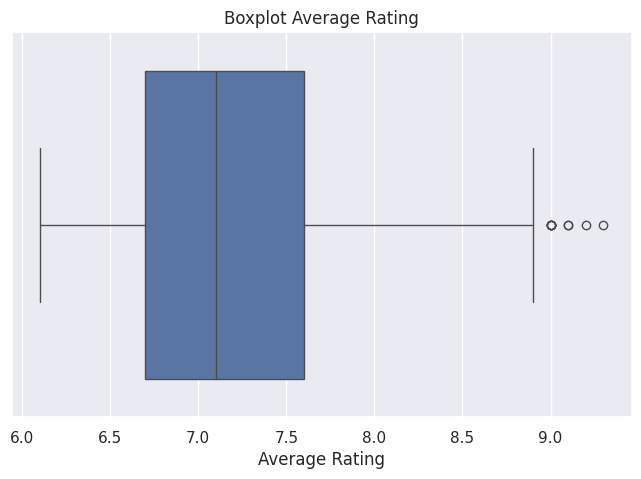

In [18]:
# Boxplot untuk melihat kemungkinan outlier pada rating
plt.figure(figsize=(8, 5))
sns.boxplot(x=movie["averageRating"])
plt.title("Boxplot Average Rating")
plt.xlabel("Average Rating")
plt.show()

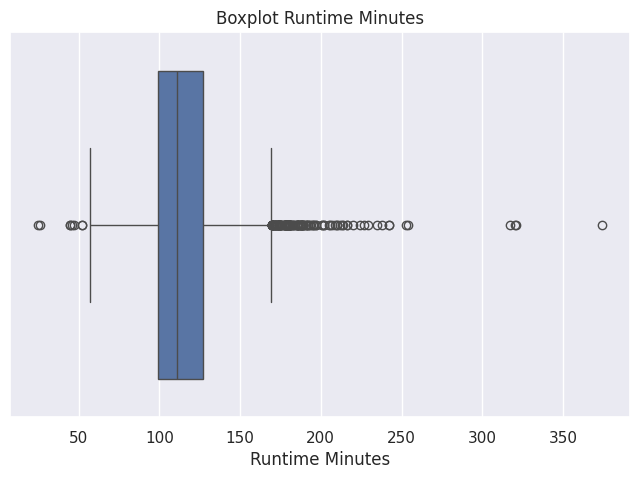

In [19]:
# Boxplot untuk melihat kemungkinan outlier pada durasi film
plt.figure(figsize=(8, 5))
sns.boxplot(x=movie["runtimeMinutes"])
plt.title("Boxplot Runtime Minutes")
plt.xlabel("Runtime Minutes")
plt.show()

### Validasi dan Keputusan Penanganan Outlier

Pada tahap ini dilakukan validasi outlier terhadap kolom numerik `averageRating` dan `runtimeMinutes` menggunakan metode IQR (Interquartile Range). Outlier dihitung berdasarkan batas bawah dan batas atas dari nilai Q1 dan Q3.

Hasil perhitungan menunjukkan bahwa terdapat 9 outlier pada kolom `averageRating` dan 150 outlier pada kolom `runtimeMinutes`. Outlier pada `averageRating` berada pada sisi Q3, yaitu film-film dengan rating sangat tinggi. Sementara itu, outlier pada `runtimeMinutes` berada pada sisi Q1 dan Q3, yaitu film dengan durasi sangat pendek atau sangat panjang.

In [20]:
# Menentukan kolom numerik yang akan divalidasi outlier-nya
outlier_columns = ["averageRating", "runtimeMinutes"]

# Membuat fungsi untuk menghitung outlier menggunakan metode IQR
def hitung_outlier_iqr(data, column):
    # Menghitung Q1 atau kuartil pertama
    Q1 = data[column].quantile(0.25)

    # Menghitung Q3 atau kuartil ketiga
    Q3 = data[column].quantile(0.75)

    # Menghitung nilai IQR
    IQR = Q3 - Q1

    # Menentukan batas bawah outlier
    lower_bound = Q1 - (1.5 * IQR)

    # Menentukan batas atas outlier
    upper_bound = Q3 + (1.5 * IQR)

    # Mengambil data yang berada di bawah batas bawah
    outlier_q1 = data[data[column] < lower_bound].copy()

    # Mengambil data yang berada di atas batas atas
    outlier_q3 = data[data[column] > upper_bound].copy()

    # Membuat ringkasan hasil perhitungan outlier
    hasil = {
        "Kolom": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Sisi Q1": len(outlier_q1),
        "Outlier Sisi Q3": len(outlier_q3),
        "Total Outlier": len(outlier_q1) + len(outlier_q3)
    }

    # Mengembalikan ringkasan dan detail outlier
    return hasil, outlier_q1, outlier_q3


# Membuat list untuk menyimpan ringkasan outlier
summary_outlier = []

# Membuat dataframe kosong untuk menyimpan detail record outlier
detail_outlier = pd.DataFrame()

# Melakukan perulangan untuk setiap kolom numerik
for col in outlier_columns:
    # Menghitung outlier pada kolom tertentu
    hasil, outlier_q1, outlier_q3 = hitung_outlier_iqr(movie, col)

    # Menambahkan hasil ringkasan ke dalam list
    summary_outlier.append(hasil)

    # Memberi keterangan pada outlier sisi Q1
    outlier_q1["kolom_outlier"] = col
    outlier_q1["posisi_outlier"] = "Sisi Q1 / Lower Outlier"

    # Memberi keterangan pada outlier sisi Q3
    outlier_q3["kolom_outlier"] = col
    outlier_q3["posisi_outlier"] = "Sisi Q3 / Upper Outlier"

    # Menggabungkan semua record outlier
    detail_outlier = pd.concat([detail_outlier, outlier_q1, outlier_q3])

# Mengubah ringkasan outlier menjadi dataframe
summary_outlier_df = pd.DataFrame(summary_outlier)

# Menampilkan ringkasan hasil outlier
summary_outlier_df

,Kolom,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Sisi Q1,Outlier Sisi Q3,Total Outlier
0,averageRating,6.7,7.6,0.9,5.35,8.95,0,9,9
1,runtimeMinutes,99.0,127.0,28.0,57.00,169.00,8,142,150


Namun, berdasarkan pemeriksaan record, outlier tersebut tidak langsung dihapus dari dataset utama karena masih memiliki makna yang valid dalam konteks film IMDb. Film dengan rating sangat tinggi seperti *The Shawshank Redemption*, *The Godfather*, dan *The Dark Knight* merupakan film populer dan berkualitas tinggi, sehingga bukan termasuk kesalahan data. Begitu pula film dengan durasi pendek atau panjang masih dapat terjadi dalam konteks film pendek, TV special, animasi pendek, atau film epik berdurasi panjang.

Oleh karena itu, keputusan penanganan outlier pada analisis ini adalah:
1. Outlier dihitung dan ditampilkan sebagai bagian dari proses validasi data.
2. Outlier tidak dihapus dari dataset utama karena masih valid secara konteks.
3. Simulasi penghapusan outlier tetap dilakukan untuk menunjukkan perubahan jumlah record apabila outlier diputuskan untuk dihapus.

##Menampilkan Record yang Termasuk Outlier

In [21]:
# Menentukan kolom yang akan ditampilkan agar output lebih mudah dibaca
kolom_tampil = [
    "primaryTitle",
    "startYear",
    "averageRating",
    "runtimeMinutes",
    "kolom_outlier",
    "posisi_outlier"
]

# Menampilkan sebagian record yang terdeteksi sebagai outlier
detail_outlier[kolom_tampil].head(20)

,primaryTitle,startYear,averageRating,runtimeMinutes,kolom_outlier,posisi_outlier
0,The Shawshank Redemption,1994,9.3,142,averageRating,Sisi Q3 / Upper Outlier
1,The Godfather,1972,9.2,175,averageRating,Sisi Q3 / Upper Outlier
2,The Dark Knight,2008,9.1,152,averageRating,Sisi Q3 / Upper Outlier
3,The Lord of the Rings: The Return of the King,2003,9.0,201,averageRating,Sisi Q3 / Upper Outlier
4,Schindler's List,1993,9.0,195,averageRating,Sisi Q3 / Upper Outlier
5,The Godfather Part II,1974,9.0,202,averageRating,Sisi Q3 / Upper Outlier
6,12 Angry Men,1957,9.0,96,averageRating,Sisi Q3 / Upper Outlier
71,The Chaos Class,1975,9.1,85,averageRating,Sisi Q3 / Upper Outlier
147,Attack on Titan: The Last Attack,2024,9.0,145,averageRating,Sisi Q3 / Upper Outlier
308,How the Grinch Stole Christmas!,1966,8.3,26,runtimeMinutes,Sisi Q1 / Lower Outlier


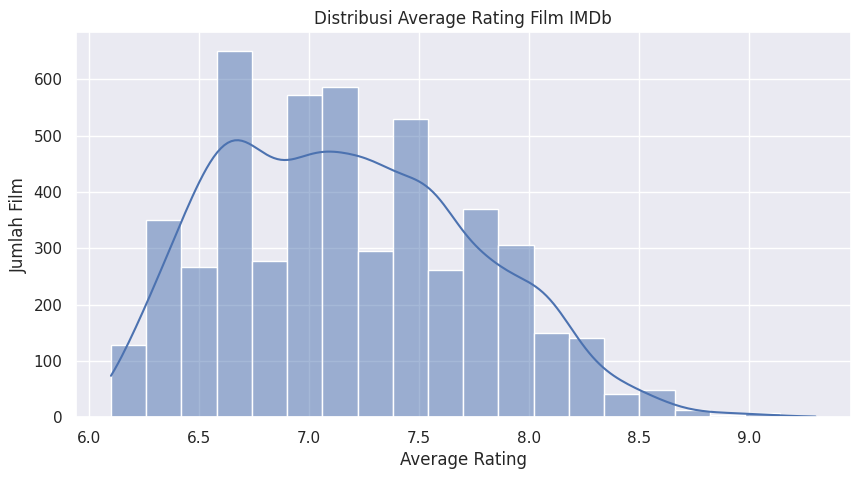

In [22]:
# Histogram distribusi rating film
plt.figure(figsize=(10, 5))
sns.histplot(movie["averageRating"], bins=20, kde=True)
plt.title("Distribusi Average Rating Film IMDb")
plt.xlabel("Average Rating")
plt.ylabel("Jumlah Film")
plt.show()

# Unit 5 - Menentukan Objek Data
Pada bagian ini dilakukan pemilihan atribut/kolom dan record/baris yang relevan untuk analisis.  
Kolom link seperti `IMDbLink` dan `Title_IMDb_Link` tidak digunakan sebagai objek analisis utama karena lebih berfungsi sebagai tautan, bukan fitur analitik.

## Menyiapkan Dataset Objek Analisis untuk Looker Studio

Pada tahap ini kolom `genres`, `directors`, dan `writers` dipisahkan agar setiap genre, sutradara, dan penulis dapat dianalisis satu per satu di Google Looker Studio. Jika kolom tersebut tetap berbentuk gabungan seperti `Crime, Drama` atau `Mario Puzo, Francis Ford Coppola`, maka Looker Studio akan membaca gabungan tersebut sebagai satu kategori.

Agar data lebih siap digunakan untuk visualisasi Business Intelligence, dataset disusun dalam format long data dengan tambahan kolom `attribute_type` dan `attribute_name`. Kolom `attribute_type` menunjukkan jenis atribut, yaitu genre, director, atau writer. Kolom `attribute_name` berisi nama atribut yang sudah dipisahkan. Format ini memudahkan pembuatan grafik seperti jumlah film berdasarkan genre, top sutradara, top penulis, serta rata-rata rating berdasarkan atribut tertentu.

In [23]:
# Membuat dataset untuk Looker Studio
movie_looker = movie.copy()

# Kolom dasar yang tetap dipertahankan
base_columns = [
    "tconst",
    "primaryTitle",
    "startYear",
    "rank",
    "averageRating",
    "numVotes",
    "runtimeMinutes",
    "directors",
    "writers",
    "genres"
]

# Membuat data genre
movie_genre = movie_looker[base_columns].copy()
movie_genre["attribute_type"] = "genre"
movie_genre["attribute_name"] = movie_genre["genres"].str.split(",")

# Membuat data director
movie_director = movie_looker[base_columns].copy()
movie_director["attribute_type"] = "director"
movie_director["attribute_name"] = movie_director["directors"].str.split(",")

# Membuat data writer
movie_writer = movie_looker[base_columns].copy()
movie_writer["attribute_type"] = "writer"
movie_writer["attribute_name"] = movie_writer["writers"].str.split(",")

# Menggabungkan genre, director, dan writer dalam satu dataset
movie_looker = pd.concat(
    [movie_genre, movie_director, movie_writer],
    ignore_index=True
)

# Memisahkan nilai dalam list menjadi baris terpisah
movie_looker = movie_looker.explode("attribute_name")

# Membersihkan spasi pada nama atribut
movie_looker["attribute_name"] = movie_looker["attribute_name"].str.strip()

## Menentukan Attributes dan Records

In [24]:
# Menentukan atribut/kolom yang dipakai sebagai objek analisis
selected_columns = [
    "tconst",
    "primaryTitle",
    "startYear",
    "rank",
    "averageRating",
    "numVotes",
    "runtimeMinutes",
    "directors",
    "writers",
    "genres",
    "attribute_type",
    "attribute_name"
]

# Membentuk dataframe baru berdasarkan atribut yang dipilih
movie_object = movie_looker[selected_columns].copy()

# Menampilkan hasil seleksi objek data
movie_object.head(10)

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,attribute_type,attribute_name
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3193141,142,Frank Darabont,"Frank Darabont, Stephen King",Drama,genre,Drama
1,tt0068646,The Godfather,1972,2,9.2,2228974,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama",genre,Crime
1,tt0068646,The Godfather,1972,2,9.2,2228974,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama",genre,Drama
2,tt0468569,The Dark Knight,2008,3,9.1,3173646,152,Christopher Nolan,"David S. Goyer, Jonathan Nolan, Christopher No...","Crime, Thriller",genre,Crime
2,tt0468569,The Dark Knight,2008,3,9.1,3173646,152,Christopher Nolan,"David S. Goyer, Jonathan Nolan, Christopher No...","Crime, Thriller",genre,Thriller
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2166974,201,Peter Jackson,"Philippa Boyens, Fran Walsh, Peter Jackson, J....","Adventure, Drama, Fantasy",genre,Adventure
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2166974,201,Peter Jackson,"Philippa Boyens, Fran Walsh, Peter Jackson, J....","Adventure, Drama, Fantasy",genre,Drama
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2166974,201,Peter Jackson,"Philippa Boyens, Fran Walsh, Peter Jackson, J....","Adventure, Drama, Fantasy",genre,Fantasy
4,tt0108052,Schindler's List,1993,5,9.0,1586572,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History",genre,Biography
4,tt0108052,Schindler's List,1993,5,9.0,1586572,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History",genre,Drama


In [25]:
movie_object.tail()

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,attribute_type,attribute_name
14997,tt28142095,Tere Ishk Mein,2025,4998,6.2,31758,167,Aanand L. Rai,"Himanshu Sharma, Neeraj Yadav","Action, Drama, Musical",writer,Himanshu Sharma
14997,tt28142095,Tere Ishk Mein,2025,4998,6.2,31758,167,Aanand L. Rai,"Himanshu Sharma, Neeraj Yadav","Action, Drama, Musical",writer,Neeraj Yadav
14998,tt0218817,Antitrust,2001,4999,6.1,31437,108,Peter Howitt,Howard Franklin,"Action, Crime, Drama",writer,Howard Franklin
14999,tt0396652,Ice Princess,2005,5000,6.1,31322,98,Tim Fywell,"Hadley Davis, Meg Cabot","Comedy, Drama, Family",writer,Hadley Davis
14999,tt0396652,Ice Princess,2005,5000,6.1,31322,98,Tim Fywell,"Hadley Davis, Meg Cabot","Comedy, Drama, Family",writer,Meg Cabot


In [26]:
# Menampilkan jumlah kolom dan baris pada objek data terpilih
print(f"Jumlah kolom objek data: {movie_object.shape[1]}")
print(f"Jumlah baris objek data : {movie_object.shape[0]}")

Jumlah kolom objek data: 12
Jumlah baris objek data : 31335


## Membentuk Specs dan Score

In [28]:
# Membuat data unik agar setiap film hanya dihitung satu kali
movie_unique = movie_object.drop_duplicates(subset="tconst").copy()

# Merapikan index setelah menghapus duplikasi film
movie_unique = movie_unique.reset_index(drop=True)

# Specs berisi fitur/atribut numerik yang dapat digunakan untuk analisis
Specs = movie_unique[["startYear", "rank", "numVotes", "runtimeMinutes"]].copy()

# Score berisi target/nilai yang ingin dianalisis
Score = movie_unique[["averageRating"]].copy()

# Menampilkan 5 data awal Specs
Specs.head()

,startYear,rank,numVotes,runtimeMinutes
0,1994,1,3193141,142
1,1972,2,2228974,175
2,2008,3,3173646,152
3,2003,4,2166974,201
4,1993,5,1586572,195


In [29]:
# Menampilkan 5 data awal Score
Score.head()

,averageRating
0,9.3
1,9.2
2,9.1
3,9.0
4,9.0


## Membuat DataFrame Insight dari Dataset IMDb

Pada tahap ini, insight dari dataset IMDb disajikan dalam bentuk dataframe. Dataframe dibuat untuk menampilkan beberapa temuan awal, seperti film dengan rating tertinggi, film dengan jumlah votes terbanyak, hubungan antara rating dan votes, distribusi durasi film, persebaran film berdasarkan tahun rilis, genre terbanyak, sutradara yang paling sering muncul, dan penulis yang paling sering muncul.

Data yang digunakan adalah dataframe `movie` karena dataframe ini masih merepresentasikan satu film sebagai satu baris. Hal ini dilakukan agar hasil perhitungan tidak mengalami penggandaan data.

In [30]:
# Membuat salinan dataset utama untuk kebutuhan insight
movie_insight = movie.copy()

# Memastikan kolom writers tidak memiliki nilai kosong
movie_insight["writers"] = movie_insight["writers"].fillna("unamed")

# Menampilkan jumlah baris dan kolom dataset insight
print("Jumlah baris dataset insight:", movie_insight.shape[0])
print("Jumlah kolom dataset insight:", movie_insight.shape[1])

Jumlah baris dataset insight: 5000
Jumlah kolom dataset insight: 12


## Cell Program DataFrame Insight

In [31]:
# Import display agar beberapa dataframe bisa ditampilkan dalam satu cell
from IPython.display import display

# 1. DataFrame daftar fitur yang dapat menjadi insight
fitur_insight_df = pd.DataFrame({
    "Fitur": [
        "tconst",
        "primaryTitle",
        "startYear",
        "rank",
        "averageRating",
        "numVotes",
        "runtimeMinutes",
        "directors",
        "writers",
        "genres"
    ],
    "Jenis Insight": [
        "Identitas film",
        "Judul film",
        "Persebaran tahun rilis",
        "Peringkat film",
        "Rating tertinggi dan kualitas film",
        "Popularitas berdasarkan jumlah votes",
        "Distribusi durasi film",
        "Sutradara yang paling sering muncul",
        "Penulis yang paling sering muncul",
        "Genre film yang paling banyak muncul"
    ]
})

# Menampilkan dataframe fitur insight
display(fitur_insight_df)

,Fitur,Jenis Insight
0,tconst,Identitas film
1,primaryTitle,Judul film
2,startYear,Persebaran tahun rilis
3,rank,Peringkat film
4,averageRating,Rating tertinggi dan kualitas film
5,numVotes,Popularitas berdasarkan jumlah votes
6,runtimeMinutes,Distribusi durasi film
7,directors,Sutradara yang paling sering muncul
8,writers,Penulis yang paling sering muncul
9,genres,Genre film yang paling banyak muncul


## Cell Program Film Rating Tertinggi

In [32]:
# 2. DataFrame daftar film dengan rating tertinggi
top_rating_df = movie_insight.sort_values(
    by=["averageRating", "numVotes"],
    ascending=[False, False]
)[
    ["primaryTitle", "startYear", "genres", "averageRating", "numVotes", "runtimeMinutes"]
].head(10)

# Menampilkan dataframe film dengan rating tertinggi
top_rating_df

,primaryTitle,startYear,genres,averageRating,numVotes,runtimeMinutes
0,The Shawshank Redemption,1994,Drama,9.3,3193141,142
1,The Godfather,1972,"Crime, Drama",9.2,2228974,175
2,The Dark Knight,2008,"Crime, Thriller",9.1,3173646,152
71,The Chaos Class,1975,Comedy,9.1,46282,85
3,The Lord of the Rings: The Return of the King,2003,"Adventure, Drama, Fantasy",9.0,2166974,201
4,Schindler's List,1993,"Biography, Drama, History",9.0,1586572,195
5,The Godfather Part II,1974,"Crime, Drama",9.0,1496337,202
6,12 Angry Men,1957,"Crime, Drama",9.0,985221,96
147,Attack on Titan: The Last Attack,2024,"Action, Adventure, Animation",9.0,29717,145
7,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure, Drama, Fantasy",8.9,2209192,178


## Cell Program Film Votes Terbanyak

In [33]:
# 3. DataFrame daftar film dengan jumlah votes terbanyak
top_votes_df = movie_insight.sort_values(
    by="numVotes",
    ascending=False
)[
    ["primaryTitle", "startYear", "genres", "averageRating", "numVotes", "runtimeMinutes"]
].head(10)

# Menampilkan dataframe film dengan jumlah votes terbanyak
top_votes_df

,primaryTitle,startYear,genres,averageRating,numVotes,runtimeMinutes
0,The Shawshank Redemption,1994,Drama,9.3,3193141,142
2,The Dark Knight,2008,"Crime, Thriller",9.1,3173646,152
8,Inception,2010,"Adventure, Sci-Fi, Thriller",8.8,2821979,148
9,Fight Club,1999,"Crime, Drama, Thriller",8.8,2613469,139
14,Interstellar,2014,"Adventure, Drama, Sci-Fi",8.7,2537875,169
10,Forrest Gump,1994,"Drama, Romance",8.8,2499765,142
11,Pulp Fiction,1994,"Crime, Drama",8.8,2438216,154
15,The Matrix,1999,"Action, Sci-Fi",8.7,2250969,136
1,The Godfather,1972,"Crime, Drama",9.2,2228974,175
7,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure, Drama, Fantasy",8.9,2209192,178


In [34]:
# 4. DataFrame hubungan antara averageRating dan numVotes
from IPython.display import display

rating_votes_corr = movie_insight[["averageRating", "numVotes"]].corr().loc["averageRating", "numVotes"]

rating_votes_df = pd.DataFrame({
    "Fitur 1": ["averageRating"],
    "Fitur 2": ["numVotes"],
    "Nilai Korelasi": [rating_votes_corr],
    "Interpretasi": [
        "Korelasi positif menunjukkan bahwa film dengan rating lebih tinggi cenderung memiliki jumlah votes yang lebih banyak."
    ]
})

# Menampilkan dataframe korelasi rating dan votes
rating_votes_df

,Fitur 1,Fitur 2,Nilai Korelasi,Interpretasi
0,averageRating,numVotes,0.391938,Korelasi positif menunjukkan bahwa film dengan...


In [35]:
from IPython.display import display

pd.set_option('display.max_colwidth', None)
display(rating_votes_df)

,Fitur 1,Fitur 2,Nilai Korelasi,Interpretasi
0,averageRating,numVotes,0.391938,Korelasi positif menunjukkan bahwa film dengan rating lebih tinggi cenderung memiliki jumlah votes yang lebih banyak.


In [36]:
# 5. DataFrame distribusi durasi film berdasarkan kategori
movie_insight["kategori_durasi"] = pd.cut(
    movie_insight["runtimeMinutes"],
    bins=[0, 90, 120, 180, movie_insight["runtimeMinutes"].max()],
    labels=["Pendek", "Sedang", "Panjang", "Sangat Panjang"]
)

durasi_df = movie_insight.groupby("kategori_durasi", observed=True).agg(
    jumlah_film=("tconst", "count"),
    rata_rata_rating=("averageRating", "mean"),
    rata_rata_votes=("numVotes", "mean")
).reset_index()

# Menampilkan dataframe distribusi durasi film
durasi_df

,kategori_durasi,jumlah_film,rata_rata_rating,rata_rata_votes
0,Pendek,462,7.141342,109438.387446
1,Sedang,2858,7.059027,138407.709237
2,Panjang,1606,7.366999,231129.844956
3,Sangat Panjang,74,7.848649,260480.527027


In [37]:
# 6. DataFrame persebaran film berdasarkan dekade rilis
movie_insight["dekade"] = (movie_insight["startYear"] // 10 * 10).astype(str) + "an"

tahun_rilis_df = movie_insight.groupby("dekade").agg(
    jumlah_film=("tconst", "count"),
    rata_rata_rating=("averageRating", "mean"),
    rata_rata_votes=("numVotes", "mean")
).reset_index()

# Mengurutkan berdasarkan dekade
tahun_rilis_df = tahun_rilis_df.sort_values(by="dekade")

# Menampilkan dataframe persebaran tahun rilis
tahun_rilis_df

,dekade,jumlah_film,rata_rata_rating,rata_rata_votes
0,1920an,12,8.083333,92164.916667
1,1930an,31,7.851613,102541.419355
2,1940an,61,7.818033,96259.819672
3,1950an,104,7.705769,105698.759615
4,1960an,148,7.675676,103466.371622
5,1970an,220,7.418636,132654.586364
6,1980an,414,7.174879,137601.990338
7,1990an,712,7.136798,184592.914326
8,2000an,1143,7.148994,200152.511811
9,2010an,1462,7.110260,187665.079343


In [38]:
# 7. DataFrame genre film yang paling banyak muncul
genre_df = movie_insight.copy()

# Memisahkan genre yang lebih dari satu
genre_df["genre"] = genre_df["genres"].str.split(",")

# Mengubah genre menjadi satu baris per genre
genre_df = genre_df.explode("genre")

# Membersihkan spasi pada genre
genre_df["genre"] = genre_df["genre"].str.strip()

# Menghitung jumlah film dan rata-rata rating per genre
top_genre_df = genre_df.groupby("genre").agg(
    jumlah_film=("tconst", "count"),
    rata_rata_rating=("averageRating", "mean"),
    rata_rata_votes=("numVotes", "mean")
).reset_index()

# Mengurutkan berdasarkan jumlah film terbanyak
top_genre_df = top_genre_df.sort_values(by="jumlah_film", ascending=False).head(10)

# Menampilkan dataframe genre terbanyak
top_genre_df

,genre,jumlah_film,rata_rata_rating,rata_rata_votes
7,Drama,3207,7.248269,143465.097599
4,Comedy,1617,7.052690,139657.867038
5,Crime,1112,7.160522,158838.552158
0,Action,1087,7.083257,222933.158234
1,Adventure,908,7.175330,266143.274229
20,Thriller,787,7.081194,182685.204574
17,Romance,771,7.107652,117719.770428
15,Mystery,548,7.095620,170508.304745
3,Biography,515,7.297282,132343.811650
12,Horror,446,6.886996,151321.890135


In [39]:
# 8. DataFrame sutradara yang paling sering muncul
director_df = movie_insight.copy()

# Memisahkan directors yang lebih dari satu
director_df["director"] = director_df["directors"].str.split(",")

# Mengubah director menjadi satu baris per director
director_df = director_df.explode("director")

# Membersihkan spasi pada nama director
director_df["director"] = director_df["director"].str.strip()

# Menghitung jumlah film dan rata-rata rating per director
top_director_df = director_df.groupby("director").agg(
    jumlah_film=("tconst", "count"),
    rata_rata_rating=("averageRating", "mean"),
    rata_rata_votes=("numVotes", "mean")
).reset_index()

# Mengurutkan berdasarkan jumlah film terbanyak
top_director_df = top_director_df.sort_values(by="jumlah_film", ascending=False).head(10)

# Menampilkan dataframe sutradara paling sering muncul
top_director_df

,director,jumlah_film,rata_rata_rating,rata_rata_votes
2444,Woody Allen,40,7.045000,82823.850000
445,Clint Eastwood,31,7.193548,194042.161290
2221,Steven Spielberg,31,7.516129,490643.677419
94,Alfred Hitchcock,27,7.592593,149169.925926
1516,Martin Scorsese,23,7.643478,505546.217391
1952,Ridley Scott,21,7.271429,416967.666667
2220,Steven Soderbergh,19,6.894737,155837.526316
2031,Ron Howard,19,7.121053,235332.526316
1120,Joel Coen,17,7.494118,318291.117647
2006,Robert Zemeckis,17,7.258824,466588.647059


In [40]:
# 9. DataFrame penulis yang paling sering muncul
writer_df = movie_insight.copy()

# Memisahkan writers yang lebih dari satu
writer_df["writer"] = writer_df["writers"].str.split(",")

# Mengubah writer menjadi satu baris per writer
writer_df = writer_df.explode("writer")

# Membersihkan spasi pada nama writer
writer_df["writer"] = writer_df["writer"].str.strip()

# Menghitung jumlah film dan rata-rata rating per writer
top_writer_df = writer_df.groupby("writer").agg(
    jumlah_film=("tconst", "count"),
    rata_rata_rating=("averageRating", "mean"),
    rata_rata_votes=("numVotes", "mean")
).reset_index()

# Mengurutkan berdasarkan jumlah film terbanyak
top_writer_df = top_writer_df.sort_values(by="jumlah_film", ascending=False).head(10)

# Menampilkan dataframe penulis paling sering muncul
top_writer_df

,writer,jumlah_film,rata_rata_rating,rata_rata_votes
7034,Woody Allen,41,7.058537,81527.414634
6227,Stan Lee,30,7.323333,788197.466667
2827,Jack Kirby,28,7.378571,785574.642857
6277,Stephen King,26,7.130769,387086.576923
7123,unamed,25,7.784000,38476.120000
2705,Ian Fleming,20,6.970000,224571.750000
3308,Joel Coen,19,7.484211,313414.263158
117,Akira Kurosawa,19,7.810526,111548.842105
4168,Luc Besson,18,6.950000,213925.666667
2044,Ethan Coen,18,7.505556,328353.277778


## Korelasi antara Fitur Numerik

In [41]:
# Mengecek korelasi antar fitur numerik
correlation_matrix = movie_object.corr(numeric_only=True)
correlation_matrix

,startYear,rank,averageRating,numVotes,runtimeMinutes
startYear,1.000000,0.258337,-0.269749,0.061259,0.125867
rank,0.258337,1.000000,-0.973065,-0.371093,-0.254247
averageRating,-0.269749,-0.973065,1.000000,0.396996,0.275793
numVotes,0.061259,-0.371093,0.396996,1.000000,0.178831
runtimeMinutes,0.125867,-0.254247,0.275793,0.178831,1.000000


In [42]:
# Mengecek jumlah baris dan kolom pada objek data
print("Jumlah baris objek data :", movie_object.shape[0])
print("Jumlah kolom objek data :", movie_object.shape[1])

Jumlah baris objek data : 31335
Jumlah kolom objek data : 12


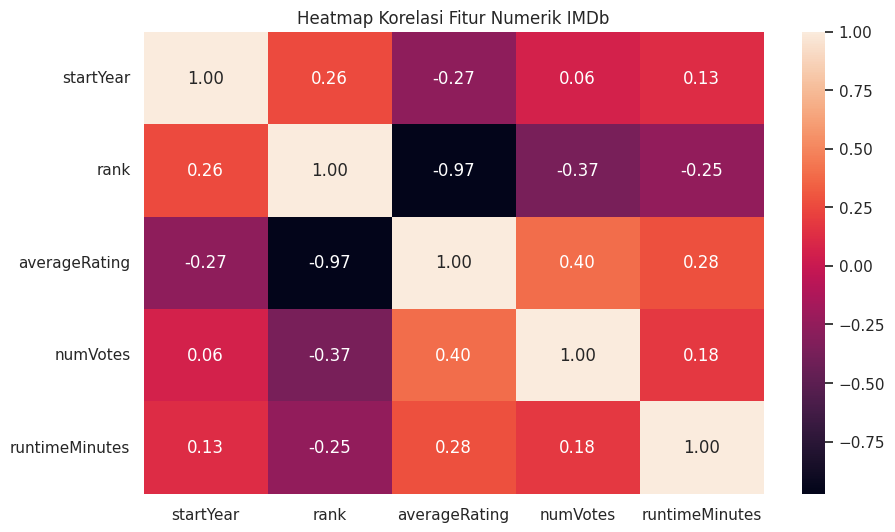

In [43]:
# Visualisasi korelasi fitur numerik dengan heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik IMDb")
plt.show()

## Sistem Rekomendasi Berdasarkan Demographic Filtering


In [44]:
# Sistem Rekomendasi berdasarkan Demographic Filtering
# Menggunakan dataset movie agar 1 film tetap 1 baris

# Membuat data salinan dari dataset utama
data_demo = movie.copy()

# Menghapus duplikasi berdasarkan kode film jika ada
data_demo = data_demo.drop_duplicates(subset="tconst").copy()

# C = rata-rata rating seluruh film
C = data_demo["averageRating"].mean()

# m = batas minimum jumlah votes, menggunakan quantile 90%
m = data_demo["numVotes"].quantile(0.90)

print("Rata-rata rating seluruh film (C):", C)
print("Minimum votes yang digunakan (m):", m)

# Memilih film yang jumlah votes-nya memenuhi batas minimum
qualified_movies = data_demo[data_demo["numVotes"] >= m].copy()

# Membuat fungsi weighted rating
def weighted_rating(x, m=m, C=C):
    v = x["numVotes"]
    R = x["averageRating"]
    return (v / (v + m) * R) + (m / (v + m) * C)

# Menghitung skor rekomendasi
qualified_movies["weighted_score"] = qualified_movies.apply(weighted_rating, axis=1)

# Mengurutkan film berdasarkan weighted_score tertinggi
demographic_recommendation = qualified_movies.sort_values(
    by="weighted_score",
    ascending=False
)

# Menampilkan 30 rekomendasi film terbaik
demographic_recommendation[
    ["primaryTitle", "startYear", "genres", "averageRating", "numVotes", "weighted_score"]
].head(10)

Rata-rata rating seluruh film (C): 7.177239999999999
Minimum votes yang digunakan (m): 404809.60000000003


,primaryTitle,startYear,genres,averageRating,numVotes,weighted_score
0,The Shawshank Redemption,1994,Drama,9.3,3193141,9.061166
1,The Godfather,1972,"Crime, Drama",9.2,2228974,8.889104
2,The Dark Knight,2008,"Crime, Thriller",9.1,3173646,8.882489
3,The Lord of the Rings: The Return of the King,2003,"Adventure, Drama, Fantasy",9.0,2166974,8.713090
7,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure, Drama, Fantasy",8.9,2209192,8.633210
4,Schindler's List,1993,"Biography, Drama, History",9.0,1586572,8.629468
5,The Godfather Part II,1974,"Crime, Drama",9.0,1496337,8.611881
8,Inception,2010,"Adventure, Sci-Fi, Thriller",8.8,2821979,8.596420
9,Fight Club,1999,"Crime, Drama, Thriller",8.8,2613469,8.582356
10,Forrest Gump,1994,"Drama, Romance",8.8,2499765,8.573836


### Penjelasan Output Demographic Filtering

Berdasarkan hasil output, nilai rata-rata rating seluruh film atau **C** adalah **7.17724**, sedangkan minimum votes atau **m** adalah **404809.6**. Nilai tersebut digunakan untuk memilih film yang memiliki jumlah votes cukup tinggi agar rekomendasi tidak hanya berdasarkan rating, tetapi juga mempertimbangkan popularitas film.

Sistem rekomendasi ini menggunakan **weighted score**, yaitu skor yang menggabungkan `averageRating` dan `numVotes`. Hasilnya menunjukkan bahwa **The Shawshank Redemption** menjadi rekomendasi teratas dengan rating **9.3**, jumlah votes **3.193.141**, dan weighted score **9.061166**. Film lain seperti **The Godfather**, **The Dark Knight**, **Inception**, dan **Fight Club** juga masuk rekomendasi karena memiliki rating tinggi dan jumlah votes besar.

Dengan demikian, metode **demographic filtering** berhasil memberikan rekomendasi film populer dan berkualitas berdasarkan rating dan jumlah votes.

## Sistem Rekomendasi Berbasis Konten

Pada tahap ini dibuat sistem rekomendasi berbasis konten atau content-based filtering. Rekomendasi diberikan berdasarkan kemiripan karakteristik film. Fitur yang digunakan adalah `genres`, `directors`, dan `writers`. Ketiga fitur tersebut digabungkan menjadi satu fitur teks, kemudian dihitung tingkat kemiripannya menggunakan TF-IDF dan cosine similarity.


In [45]:
# Sistem Rekomendasi Berbasis Konten
# Menggunakan versi hemat RAM agar tidak membuat session Colab crash

# Import library untuk content-based filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Membuat salinan data dari dataset utama
data_content = movie.copy()

# Menghapus duplikasi berdasarkan kode film jika ada
data_content = data_content.drop_duplicates(subset="tconst").copy()

# Merapikan index agar proses rekomendasi lebih aman
data_content = data_content.reset_index(drop=True)

# Daftar fitur yang digunakan untuk content-based filtering
content_features = ["genres", "directors", "writers"]

# Mengisi nilai kosong dan memastikan data berbentuk string
for col in content_features:
    data_content[col] = data_content[col].fillna("").astype(str)

# Menggabungkan fitur genres, directors, dan writers menjadi satu kolom
data_content["content_features"] = (
    data_content["genres"] + " " +
    data_content["directors"] + " " +
    data_content["writers"]
)

# Mengubah teks menjadi representasi numerik menggunakan TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(data_content["content_features"])

# Membuat index berdasarkan judul film
indices = pd.Series(
    data_content.index,
    index=data_content["primaryTitle"]
).drop_duplicates()

# Membuat fungsi rekomendasi berbasis konten
def content_recommendation(title, n=10):
    idx = indices[title]

    # Menghitung similarity hanya untuk film yang dicari
    sim_scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Mengurutkan skor similarity dari tertinggi ke terendah
    sim_indices = sim_scores.argsort()[::-1]

    # Menghapus film itu sendiri dari hasil rekomendasi
    sim_indices = [i for i in sim_indices if i != idx]

    # Mengambil n rekomendasi teratas
    top_indices = sim_indices[:n]

    # Membentuk tabel hasil rekomendasi
    result = data_content.iloc[top_indices][
        ["primaryTitle", "startYear", "genres", "directors", "writers", "averageRating"]
    ].copy()

    # Menambahkan nilai similarity
    result["similarity_score"] = sim_scores[top_indices]

    return result

# Contoh rekomendasi film yang mirip dengan The Dark Knight
content_recommendation("The Dark Knight", 10)

,primaryTitle,startYear,genres,directors,writers,averageRating,similarity_score
48,The Dark Knight Rises,2012,"Crime, Thriller",Christopher Nolan,"Bob Kane, David S. Goyer, Jonathan Nolan, Christopher Nolan",8.4,1.000000
97,Batman Begins,2005,Crime,Christopher Nolan,"Bob Kane, David S. Goyer, Christopher Nolan",8.2,0.955368
51,Memento,2000,"Mystery, Thriller",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.4,0.875590
14,Interstellar,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,0.847270
1478,Following,1998,"Crime, Mystery, Thriller",Christopher Nolan,Christopher Nolan,7.4,0.838475
439,Dunkirk,2017,"Action, Drama, History",Christopher Nolan,Christopher Nolan,7.8,0.806000
1761,Tenet,2020,"Action, Sci-Fi, Thriller",Christopher Nolan,Christopher Nolan,7.3,0.801012
8,Inception,2010,"Adventure, Sci-Fi, Thriller",Christopher Nolan,Christopher Nolan,8.8,0.799829
30,The Prestige,2006,"Drama, Mystery, Sci-Fi",Christopher Nolan,"Christopher Priest, Jonathan Nolan, Christopher Nolan",8.5,0.793651
106,Oppenheimer,2023,"Biography, Drama, History",Christopher Nolan,"Martin Sherwin, Christopher Nolan, Kai Bird",8.2,0.611199


### Penjelasan Output Content-Based Filtering

Output tersebut merupakan hasil sistem rekomendasi berbasis konten dengan menggunakan fitur `genres`, `directors`, dan `writers`. Ketiga fitur tersebut digunakan karena menggambarkan karakteristik isi film. Sistem akan mencari film lain yang memiliki kemiripan dengan film input berdasarkan kesamaan genre, sutradara, dan penulis.

Nilai `similarity_score` menunjukkan tingkat kemiripan antara film input dengan film yang direkomendasikan. Semakin mendekati angka 1, maka semakin tinggi tingkat kemiripan film tersebut. Sebaliknya, nilai yang mendekati 0 menunjukkan bahwa film tersebut memiliki kemiripan yang rendah dengan film input.

Dalam contoh ini, film input yang digunakan adalah The Dark Knight. Oleh karena itu, sistem akan merekomendasikan film-film yang memiliki karakteristik mirip, misalnya memiliki genre crime atau thriller, atau memiliki keterkaitan pada sutradara dan penulis seperti Christopher Nolan. Film seperti Inception dapat muncul sebagai rekomendasi karena memiliki sutradara yang sama, yaitu Christopher Nolan, serta memiliki unsur genre yang masih berdekatan.

## Menyimpan dan Download Dataset Clean

In [46]:
# Menyimpan dataset bersih versi lengkap
movie.to_csv("Top_5000_IMDb_clean.csv", index=False)

# Meyimpan dataset objek analisis
movie_object.to_csv("Top_5000_IMDb_object_selected.csv", index=False)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan
